# Toxic comment classification with BERT

The online store "Wikishop" is launching a service in which users can edit and supplement product descriptions, as in wiki communities. Along with this, toxic comments appear too, which need to be found in time and sent for moderation. Our task is to train a model that separates toxic comments from ordinary ones using a labelled dataset.

## Goal
Build a model that classifies comments into toxic and ordinary:
- the baseline solution is a classical model on a "bag of words" (TF-IDF, a measure of the importance of a word in a document);
- the main branch is text representations based on the pretrained BERT model: first frozen vector representations (embeddings), then light fine-tuning for our task;
- the value of the F1-measure metric (F1-score) on the test set is not less than 0.75.

## Data description:
The data is located in the file `toxic_comments.csv`.
- `text` the text of the comment;
- `toxic` the target feature: 1 the comment is toxic, 0 ordinary.

## Research plan

1) Data preprocessing: loading, inspection, cleaning and lemmatization of the text.
2) Exploratory data analysis: class balance and comment length.
3) Preparation of the sets for training a single split for all models.
4) A "bag of words" model (TF-IDF) the baseline solution with hyperparameter tuning.
5) Frozen embeddings of the standard BERT (`distilbert-base-uncased`) + logistic regression we will check whether the ready-made representations are sufficient without fine-tuning.
6) A conclusion about the need to fine-tune BERT (so that it catches up with the baseline solution) and fine-tuning for the task.
7) Comparison of the models on a common test subsample and final conclusions.

### Import of modules

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import nltk
from nltk import pos_tag_sents
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
import torch
from torch.utils.data import TensorDataset, DataLoader
import transformers
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_predict, GridSearchCV
from sklearn.metrics import f1_score

transformers.logging.set_verbosity_error()

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Computation device: {device}")

Устройство для вычислений: cpu


## Data preprocessing

Let us load the data. The file may lie both next to the notebook and in the trainer's directory, so we try both paths.

In [3]:
try:
    data = pd.read_csv("data/toxic_comments.csv")
except FileNotFoundError:
    data = pd.read_csv("/datasets/toxic_comments.csv")

pd.set_option("display.max_colwidth", 200)
data.head()

,Unnamed: 0,text,toxic
0,0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remo...",0
1,1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0
2,2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about...",0
3,3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tid...",0
4,4,"You, sir, are my hero. Any chance you remember what page that's on?",0


Let us remove the service column with the index (if there is one) and look at the size of the table and the data types.

In [4]:
data = data.drop(columns=["Unnamed: 0"], errors="ignore")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ MB


The dataset contains about 159 thousand comments, there are no missing values in `text` and `toxic`. The target feature is already represented by the numbers 0 and 1, there is no need to cast the types.

Let us check whether there are full duplicate rows.

In [5]:
data.duplicated().sum()

0

There are no full duplicates in the data.

Let us prepare the text for the "bag of words". We will do three steps: we will convert it to lower case and keep only Latin letters and spaces (this way punctuation, digits and service characters will go away); then we will bring the words to their base form we will lemmatize them. Lemmatization glues together different forms of the same word (`insults` and `insult`), and the feature vocabulary turns out to be more compact. For lemmatization we will take the WordNet dictionary from the `nltk` library. In order to correctly bring to the base form not only nouns, but also verbs, adjectives and adverbs, we determine the part of speech of each word (POS tags) in advance and pass it to the lemmatizer.

In [6]:
# The standard NLTK loader may fail here due to SSL, therefore we keep the corpus next to the notebook.
NLTK_DATA_DIR = Path("data/nltk_data")
NLTK_DATA_DIR.mkdir(parents=True, exist_ok=True)
nltk_data_path = str(NLTK_DATA_DIR.resolve())
if nltk_data_path not in nltk.data.path:
    nltk.data.path.insert(0, nltk_data_path)


def ensure_nltk_resource(resource_names, download_name):
    for resource_name in resource_names:
        try:
            return nltk.data.find(resource_name)
        except LookupError:
            pass
    try:
        downloaded = nltk.download(download_name, download_dir=nltk_data_path, quiet=True)
    except Exception as exc:
        raise RuntimeError(
            f"{download_name} was not found locally, and nltk.download could not download it. "
            f"Check the local files in {NLTK_DATA_DIR}."
        ) from exc
    if not downloaded:
        raise RuntimeError(f"Failed to obtain the NLTK resource: {download_name}.")
    for resource_name in resource_names:
        try:
            return nltk.data.find(resource_name)
        except LookupError:
            pass
    raise LookupError(f"{download_name} was downloaded but not found in {nltk_data_path}.")


ensure_nltk_resource(("corpora/wordnet", "corpora/wordnet.zip/wordnet/"), "wordnet")
ensure_nltk_resource(("corpora/omw-1.4", "corpora/omw-1.4.zip/omw-1.4/"), "omw-1.4")
ensure_nltk_resource(
    (
        "taggers/averaged_perceptron_tagger_eng",
        "taggers/averaged_perceptron_tagger_eng.zip/averaged_perceptron_tagger_eng/",
        "taggers/averaged_perceptron_tagger",
        "taggers/averaged_perceptron_tagger.zip/averaged_perceptron_tagger/",
    ),
    "averaged_perceptron_tagger",
)
lemmatizer = WordNetLemmatizer()


def to_wordnet_pos(treebank_tag):
    return {"J": wordnet.ADJ, "V": wordnet.VERB, "R": wordnet.ADV}.get(treebank_tag[:1], wordnet.NOUN)


def tokenize(text):
    return re.sub(r"[^a-z ]", " ", text.lower()).split()


tokenized_corpus = [tokenize(text) for text in data["text"]]
data["text_clear"] = [
    " ".join(lemmatizer.lemmatize(word, to_wordnet_pos(tag)) for word, tag in tagged)
    for tagged in pos_tag_sents(tokenized_corpus)
]
data[["text", "text_clear"]].head()

,text,text_clear
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remo...",explanation why the edits make under my username hardcore metallica fan be revert they weren t vandalism just closure on some gas after i vote at new york doll fac and please don t remove the temp...
1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",d aww he match this background colour i m seemingly stick with thanks talk january utc
2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about...",hey man i m really not try to edit war it s just that this guy be constantly remove relevant information and talk to me through edits instead of my talk page he seem to care more about the formatt...
3,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tid...",more i can t make any real suggestion on improvement i wonder if the section statistic should be later on or a subsection of type of accident i think the reference may need tidy so that they be al...
4,"You, sir, are my hero. Any chance you remember what page that's on?",you sir be my hero any chance you remember what page that s on


The cleaned text will be needed by the "bag of words". For BERT we use the original text, because the model has its own tokenizer and does not need preliminary cleaning.

## Exploratory data analysis

Let us look at the class balance what share the toxic comments occupy.

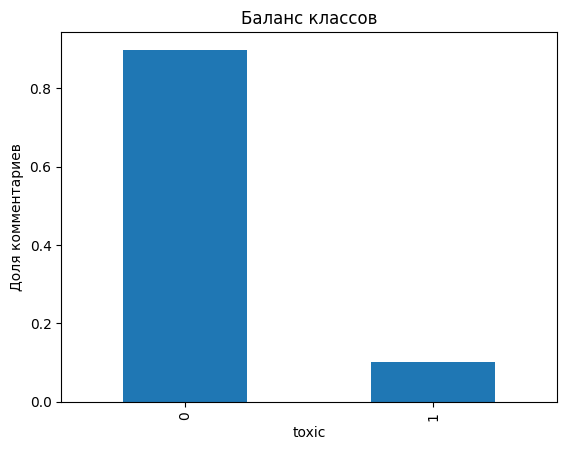

Доля токсичных комментариев: 10.2%


In [7]:
class_share = data["toxic"].value_counts(normalize=True)

_, ax = plt.subplots()
ax.set_title("Class balance")
ax.set_xlabel("Class (0 ordinary, 1 toxic)")
ax.set_ylabel("Share of comments")
class_share.plot(kind="bar", ax=ax)
plt.show()

print(f"Share of toxic comments: {data['toxic'].mean() * 100:.1f}%")

The classes are strongly imbalanced: toxic comments make up about 10%. This is important to take into account in two ways. During training we will weight the classes so that the model does not ignore the rare class. And we will evaluate the quality by the F1-measure, and not by accuracy: on imbalanced data accuracy is overstated and says almost nothing about the toxic class.

Let us look at the length of the comments in characters.

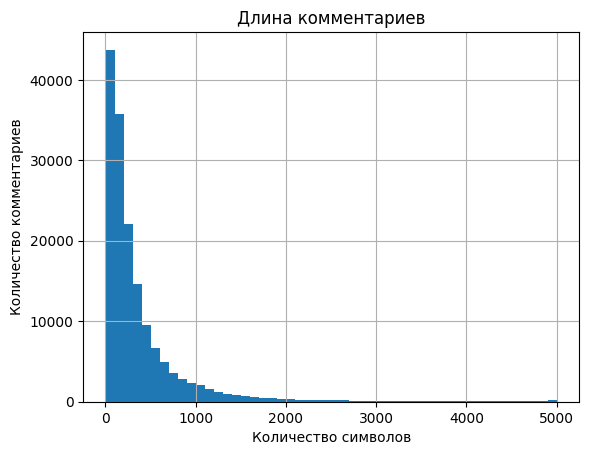

Медианная длина комментария: 205 символов


In [8]:
lengths = data["text"].str.len()

_, ax = plt.subplots()
ax.set_title("Comment length")
ax.set_xlabel("Number of characters")
ax.set_ylabel("Number of comments")
lengths.hist(bins=50, ax=ax)
plt.show()

print(f"Median comment length: {lengths.median():.0f} characters")

Most comments are short the median is about 200 characters (approximately 50 tokens), but long ones also occur, up to several thousand characters. Therefore, when working with BERT, we will limit the sequence length to 64 tokens: the median comment fits entirely, the computation remains manageable, and the training stable.

## Preparation of the sets

Let us immediately split the data into a training and a test set in a ratio of 80/20 this split will be common to all models, so that the comparison is fair. We stratify the split by the target feature, so that the share of toxic comments in both sets coincides, and we fix `random_state` for reproducibility.

In [9]:
data_train, data_test = train_test_split(
    data, test_size=0.2, stratify=data["toxic"], random_state=12345
)

print(f"Training set: {data_train.shape[0]} rows")
print(f"Test set: {data_test.shape[0]} rows")

Обучающая выборка: 127433 строк
Тестовая выборка: 31859 строк


## A "bag of words" model (TF-IDF)

The baseline solution is TF-IDF vectorization and logistic regression. We remove the English stop words right in the vectorizer: they occur almost everywhere and are useless for classification. We balance the class weights because of the imbalance. We train the vectorizer only on the training set, and the test set we only transform this way information from the test does not get into the training.

In [10]:
tf_idf_pipeline = Pipeline(
    [
        ("tfidf", TfidfVectorizer(stop_words="english")),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=12345)),
    ]
)

Let us tune the regularization strength `C` of the logistic regression. In order not to peek into the test and not to allow a leak at the vectorization stage, we will combine `TfidfVectorizer` and the model into a `Pipeline` and compare the values of `C` by F1 on cross-validation the vectorizer is refitted on each fold only on the training part.

In [11]:
param_grid = {"clf__C": [0.1, 1, 10]}
grid_search = GridSearchCV(tf_idf_pipeline, param_grid, scoring="f1", cv=3, n_jobs=-1)
grid_search.fit(data_train["text_clear"], data_train["toxic"])

for c, score in zip(param_grid["clf__C"], grid_search.cv_results_["mean_test_score"]):
    print(f"C = {c}: F1 on cross-validation = {score:.3f}")
print(f"Best value of C: {grid_search.best_params_['clf__C']}")

C = 0.1: F1 на кросс-валидации = 0.702
C = 1: F1 на кросс-валидации = 0.738
C = 10: F1 на кросс-валидации = 0.753
Лучшее значение C: 10


Let us train the final model with the selected `C` on the whole training set and evaluate it on the test.

In [12]:
model_tf_idf = grid_search.best_estimator_
f1_tf_idf = f1_score(data_test["toxic"], model_tf_idf.predict(data_test["text_clear"]))
print(f"Feature vocabulary size: {len(model_tf_idf.named_steps['tfidf'].vocabulary_)}")
print(f"F1 on the test set (TF-IDF): {f1_tf_idf:.3f}")

Размер словаря признаков: 136819
F1 на тестовой выборке (TF-IDF): 0.762


The hyperparameter C and the best model are selected by cross-validation on the training set (GridSearchCV). The test set is used exactly once for the final evaluation of the already selected model.

The TF-IDF model gave F1 = `0.760` on the full test set this is above the target threshold of 0.75. The baseline solution already fulfils the requirement of the task.

## Embeddings of the standard BERT (frozen)

Now let us turn to BERT. First we use it as a ready-made feature extractor, without changing the weights: we run the texts through the pretrained model in `torch.no_grad()` mode (without computing gradients) and take the vector of the service token `[CLS]` as the embedding of the whole comment. On top of these embeddings we train a logistic regression.

Computing the embeddings and fine-tuning on the CPU are costly, therefore for BERT we take a subsample: the training one from the common training set, the test one from the common test set. This way the BERT sets do not intersect with each other and are consistent with the split for TF-IDF. On this same subsample we will later compare the frozen and the fine-tuned models.

In [13]:
train_sample_size = 4000
test_sample_size = 3000

data_bert_train = (
    data_train.groupby("toxic", group_keys=False)
    .apply(lambda group: group.sample(int(round(len(group) * train_sample_size / len(data_train))), random_state=12345))
    .reset_index(drop=True)
)
data_bert_test = (
    data_test.groupby("toxic", group_keys=False)
    .apply(lambda group: group.sample(int(round(len(group) * test_sample_size / len(data_test))), random_state=12345))
    .reset_index(drop=True)
)
target_bert_train = data_bert_train["toxic"].values
target_bert_test = data_bert_test["toxic"].values

print(f"BERT subsample: training {data_bert_train.shape[0]}, test {data_bert_test.shape[0]}")
print(f"Share of toxic: training {target_bert_train.mean() * 100:.1f}%, test {target_bert_test.mean() * 100:.1f}%")

Подвыборка BERT: обучающая 4000, тестовая 3000
Доля токсичных: обучающая 10.2%, тестовая 10.2%


C:\Users\yka\AppData\Local\Temp\ipykernel_58420\395498781.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_train.groupby("toxic", group_keys=False)
C:\Users\yka\AppData\Local\Temp\ipykernel_58420\395498781.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_test.groupby("toxic", group_keys=False)


Let us describe the function for computing the embeddings: we compute them in small packets (batch), we split the texts into tokens with a length limit of 64 tokens. The computations run on the selected device.

In [14]:
def make_embeddings(texts, tokenizer, model, batch_size=64, max_length=64):
    embeddings = []
    model = model.to(device)
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = list(texts[i:i + batch_size])
        encoded = tokenizer(
            batch, truncation=True, max_length=max_length, padding=True, return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            output = model(**encoded)
        embeddings.append(output.last_hidden_state[:, 0, :].cpu().numpy())
    return np.concatenate(embeddings)

Let us load the ordinary pretrained BERT and compute the embeddings for the training and test subsamples.

In [15]:
tokenizer_bert = transformers.AutoTokenizer.from_pretrained("distilbert-base-uncased")
model_frozen = transformers.AutoModel.from_pretrained("distilbert-base-uncased")
model_frozen.eval()

features_train = make_embeddings(data_bert_train["text"].tolist(), tokenizer_bert, model_frozen)
features_test = make_embeddings(data_bert_test["text"].tolist(), tokenizer_bert, model_frozen)
print(f"Embedding matrix size: training {features_train.shape}, test {features_test.shape}")

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

Размер матрицы эмбеддингов: обучающая (4000, 768), тестовая (3000, 768)


Let us train a logistic regression on these embeddings.

In [16]:
model_logreg = LogisticRegression(class_weight="balanced", max_iter=1000, C=1, random_state=12345)
model_logreg.fit(features_train, target_bert_train)
predictions_frozen_cv = cross_val_predict(model_logreg, features_train, target_bert_train, cv=3)
f1_frozen_cv = f1_score(target_bert_train, predictions_frozen_cv)
print(f"F1 (frozen BERT, threshold 0.5, cross-validation on training): {f1_frozen_cv:.3f}")

F1 (замороженный BERT, порог 0.5, кросс-валидация на обучении): 0.632


Because of the imbalance, the threshold of 0.5 is not always the best. Let us tune the threshold that maximizes F1: we will estimate the probabilities on the training subsample via cross-validation (in order not to peek into the test) and apply the best threshold to the test.

In [17]:
probabilities_train = cross_val_predict(
    model_logreg, features_train, target_bert_train, cv=3, method="predict_proba"
)[:, 1]

thresholds = np.linspace(0.1, 0.9, 81)
best_threshold = thresholds[int(np.argmax(
    [f1_score(target_bert_train, (probabilities_train >= t).astype(int)) for t in thresholds]
))]

probabilities_test = model_logreg.predict_proba(features_test)[:, 1]
f1_frozen_tuned = f1_score(target_bert_test, (probabilities_test >= best_threshold).astype(int))
print(f"Best threshold: {best_threshold:.2f}")
print(f"F1 (frozen BERT, tuned threshold): {f1_frozen_tuned:.3f}")

Лучший порог: 0.78
F1 (замороженный BERT, порог подобран): 0.739


The frozen BERT, even after threshold tuning, gives F1 = `0.740` this is below the target threshold of 0.75 and below the "bag of words". Conclusion: without fine-tuning, the `[CLS]` vector of the general BERT weakly reflects toxicity specifically. Pretrained representations are suitable for many tasks, but for ours they are not tuned "out of the box". This means that in order for BERT to become competitive, its weights need to be fine-tuned on our data this is what we will do next.

## Fine-tuning of BERT (fine-tuning)

Let us fine-tune the same `distilbert-base-uncased`, but now we will update the weights of the model for our task. A classification "head" (`AutoModelForSequenceClassification`) is added on top of BERT, and the whole model is trained to predict the class of the comment.

We take the same small subsample, limit the length to 64 tokens, train two epochs in small packets. Because of the class imbalance we use a weighted loss function we give the rare toxic class a greater weight. For reproducibility we fix `random_state` before creating the model and shuffling the batches. We evaluate the model on the same test subsample as the frozen one, the comparison will be fair.

In [18]:
max_length = 64
batch_size = 16
epochs = 2
learning_rate = 2e-5


def make_loader(texts, targets, tokenizer, shuffle):
    encoded = tokenizer(
        list(texts), truncation=True, max_length=max_length, padding=True, return_tensors="pt"
    )
    dataset = TensorDataset(
        encoded["input_ids"], encoded["attention_mask"], torch.tensor(targets, dtype=torch.long)
    )
    generator = torch.Generator().manual_seed(12345) if shuffle else None
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, generator=generator)


loader_train = make_loader(data_bert_train["text"], target_bert_train, tokenizer_bert, shuffle=True)
loader_test = make_loader(data_bert_test["text"], target_bert_test, tokenizer_bert, shuffle=False)

Let us define a weighted loss function according to the class frequencies in the training subsample.

In [19]:
class_counts = np.bincount(target_bert_train)
class_weights = torch.tensor(
    [class_counts.sum() / (2.0 * count) for count in class_counts], dtype=torch.float
).to(device)
loss_function = torch.nn.CrossEntropyLoss(weight=class_weights)
print(f"Class weights: ordinary {class_weights[0]:.2f}, toxic {class_weights[1]:.2f}")

Веса классов: обычный 0.56, токсичный 4.93


Let us load the model and train it on the selected device.

In [20]:
torch.manual_seed(12345)
np.random.seed(12345)

model_finetuned = transformers.AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
).to(device)
optimizer = torch.optim.AdamW(model_finetuned.parameters(), lr=learning_rate)

for epoch in range(epochs):
    model_finetuned.train()
    epoch_loss = 0.0
    for input_ids, attention_mask, labels in tqdm(loader_train, desc=f"Epoch {epoch + 1}"):
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model_finetuned(input_ids=input_ids, attention_mask=attention_mask).logits
        loss = loss_function(logits, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch + 1}: average loss {epoch_loss / len(loader_train):.4f}")

Эпоха 1:   0%|          | 0/250 [00:00<?, ?it/s]

Эпоха 1: средняя потеря 0.3422


Эпоха 2:   0%|          | 0/250 [00:00<?, ?it/s]

Эпоха 2: средняя потеря 0.1328


Let us obtain the predictions of the fine-tuned model on the test subsample and compute F1.

In [21]:
model_finetuned.eval()
predictions = []
with torch.no_grad():
    for input_ids, attention_mask, _ in loader_test:
        input_ids, attention_mask = input_ids.to(device), attention_mask.to(device)
        logits = model_finetuned(input_ids=input_ids, attention_mask=attention_mask).logits
        predictions.append(logits.argmax(dim=1).cpu().numpy())

predictions_finetuned = np.concatenate(predictions)
f1_finetuned = f1_score(target_bert_test, predictions_finetuned)
print(f"F1 (fine-tuned BERT): {f1_finetuned:.3f}")

F1 (дообученный BERT): 0.799


The fine-tuned BERT gives F1 = `0.799` on the test subsample. Fine-tuning sharply raised the quality in comparison with the frozen embeddings the model learned to separate toxicity specifically on our data.

## Comparison of the models

So that the comparison is fair, let us evaluate all the models on one and the same test subsample. For this we will compute the F1 of the TF-IDF model on the same comments.

In [22]:
f1_tf_idf_sub = f1_score(target_bert_test, model_tf_idf.predict(data_bert_test["text_clear"]))

results = pd.DataFrame(
    {
        "Model": [
            "TF-IDF + logistic regression",
            "Frozen BERT (embeddings) + logistic regression",
            "Fine-tuned BERT (fine-tuning)",
        ],
        "F1 on the common test subsample": [f1_tf_idf_sub, f1_frozen_tuned, f1_finetuned],
    }
)
results

,Модель,F1 на общей тестовой подвыборке
0,TF-IDF + логистическая регрессия,0.758929
1,Замороженный BERT (эмбеддинги) + логистическая регрессия,0.738710
2,Дообученный BERT (fine-tuning),0.799353


On one and the same test subsample three levels are visible. The "bag of words" is a simple and strong baseline option. The frozen embeddings of the general BERT without fine-tuning are inferior to it. And the fine-tuned BERT comes out ahead tuning the weights for the task reveals its strength. Let us note that we compare the frozen model with a tuned threshold (its best result), and the fine-tuned one with the standard threshold of 0.5; even in such a comparison, which is more favourable for the frozen model, fine-tuning is confidently ahead. Let us recall: on the full test set TF-IDF gives F1 = `0.760`.

## Final conclusions

We solved the task in several ways and compared them by the F1-measure.

- TF-IDF + logistic regression F1 = `0.760` on the full test set. Above the target threshold of 0.75, the goal of the project has been achieved. This is a light and fast working model, trained from scratch on our data.
- Frozen embeddings of the standard BERT (`distilbert-base-uncased`) + logistic regression F1 = `0.740` even after threshold tuning. Below the threshold: without fine-tuning the `[CLS]` vector of the general BERT weakly reflects toxicity.
- Fine-tuned BERT (`distilbert-base-uncased`, fine-tuning) F1 = `0.799` on the test subsample. Fine-tuning for the task raised the quality above the frozen variant.

The main conclusion: BERT by itself does not guarantee a gain. The frozen embeddings of the general BERT are inferior to a careful "bag of words". The value of BERT is revealed when its weights are trained for the required task this was confirmed by the light fine-tuning.

## Conclusions

### For the business
For the search for toxic comments of "Wikishop" a light TF-IDF + logistic regression model is already sufficient: it exceeds the required quality (F1 ≥ 0.75), trains quickly and does not require powerful hardware. It can be used right away to send suspicious comments for moderation. If higher quality is needed, fine-tuning BERT on one's own data is justified even light fine-tuning noticeably raises the result.

### For analytics
The comparison showed that the frozen embeddings of the general BERT do not give a gain here without fine-tuning they are worse than the "bag of words". The gain appears only after fine-tuning the weights for our task. Therefore, when choosing an approach it is important to look not at the loud name of the model, but at for which task and on which data its weights were trained. Because of the class imbalance we evaluated the quality by F1 and weighted the classes this is worth keeping in further experiments.